# **NLP Medical Question Filtering**


***
# 0. Setup

## Imports & Utilities

In [1]:
# General imports
import os
from datetime import datetime
import time

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import uuid

# Plots
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Embedding
from sentence_transformers import SentenceTransformer

# Scikit Learn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Tensorflow, Keras
import tensorflow as tf 
import keras_tuner as kt


In [2]:
# Utility for dataset summary
#

def display_file_summary(data_frame, name=""):
    # Create a temporary df and ensure no lists remain, so that unique items can be identified for uniqueness
    temp_df = data_frame.copy()
    temp_df = temp_df.map(lambda cell: str(cell) if isinstance(cell, list) else cell)
    
    # Calculate Data Types 
    summary_of_df = pd.DataFrame({'Count': data_frame.count(),
                                 'Missing': data_frame.isnull().sum(), 'Empty': 0,
                                 'Unique': temp_df.nunique(),
                                 'Top': data_frame.apply(lambda x: x.value_counts().index[0]),
                                 'Freq': data_frame.apply(lambda x: x.value_counts().iat[0]),
                                 'Type': data_frame.dtypes, 
                                 'String': 0, 'Int': 0, 'Float': 0, 'Bool': 0, 'List': 0, 'Other': 0
                                 })
    # ?? Below with Map should not work as counting entire data frame, but counts do appear correct
    #test = data_frame['Description'].apply(lambda cell: isinstance(cell, str)).sum()
    summary_of_df['Empty'] = (data_frame == '').sum()
    summary_of_df['String'] = data_frame.map(lambda cell: isinstance(cell, str)).sum()
    summary_of_df['Int'] = data_frame.map(lambda cell: isinstance(cell, int)).sum()
    summary_of_df['Float'] = data_frame.map(lambda cell: isinstance(cell, float)).sum()
    summary_of_df['Bool'] = data_frame.map(lambda cell: isinstance(cell, bool)).sum()
    summary_of_df['List'] = data_frame.map(lambda cell: isinstance(cell, list)).sum()
    summary_of_df['Other'] = data_frame.map(lambda cell: isinstance(cell, (tuple,dict,set,type(None)))).sum()

    print(f'File Details. {name}')
    display(summary_of_df)

## Project Setup

In [3]:
# Project Setup
#

#---- Run Parameters --------------------------------
run_name = 'Test_Training_v1'

#----------------------------------------------------

# Folder paths
local_project_folder = Path.cwd().parent
data_folder = local_project_folder.joinpath('Data')
if not data_folder.exists():
    raise FileNotFoundError(f'{data_folder} does not exist')
run_results_folder = local_project_folder.joinpath(f'Results/{run_name}')
if not run_results_folder.exists():
    raise FileNotFoundError(f'{run_results_folder} does not exist')

del local_project_folder, data_folder, run_name

***
## Adversarial Attacks

## General Functions

In [4]:
# Model Details
#

def inspect_model(model):

    print(f'\n{model.summary()}')    
    for i, layer in enumerate(model.layers):
        print(f"\nLayer {i}: {layer.name} ({type(layer).__name__})")
        print(f"  - Input shape: {layer.input_shape}")
        print(f"  - Output shape: {layer.output_shape}")
        
        # Show activation function for layers that have it
        if hasattr(layer, 'activation'):
            print(f"  - Activation: {layer.activation.__name__}")
            
        # Show units for Dense layers
        if hasattr(layer, 'units'):
            print(f"  - Units: {layer.units}")
            
        # Show other layer-specific attributes
        if hasattr(layer, 'kernel_initializer') and layer.kernel_initializer is not None:
            print(f"  - Kernel initializer: {layer.kernel_initializer.__class__.__name__}")
            
        # Show parameter count for this layer
        if hasattr(layer, 'count_params'):
            print(f"  - Parameters: {layer.count_params():,}")

In [5]:
# Model Evaluation
#

def evaluate_model(model, X_test, y_test, verbose=True):

    # Model predictions
    start_time = time.perf_counter()
    y_pred_probs = model.predict(X_test)
    # y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_pred = np.argmax(y_pred_probs, axis=1) 
    duration = time.perf_counter() - start_time

    # Calculate Metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall = metrics.recall_score(y_true=y_test, y_pred=y_pred, pos_label=1)
    precision = metrics.precision_score(y_true=y_test, y_pred=y_pred, pos_label=1)
    f1_score = metrics.f1_score(y_true=y_test, y_pred=y_pred, pos_label=1)
    specificity = tn / (tn + fp)
    mcc = matthews_corrcoef(y_test, y_pred)

    # Print Metrics
    if verbose:
        print(f'\n----Evaluation Result for: {model.name} -------')
        print(f'Recall (Sensitivity, TP Rate): {recall:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'F1 Score {f1_score:.4f}')
        print(f'Specificity (1 - Fall-Out): {specificity:.4f}')
        print(f'MCC: {mcc:.4f}')
        print('-----------')
        print(f'Accuracy: {metrics.accuracy_score(y_true=y_test, y_pred=y_pred):.4f}')
        print(f'Fall Out (FPR): {fp / (fp + tn):.4f}')
        print(f'Hamming Loss {metrics.hamming_loss(y_true=y_test, y_pred=y_pred):.4f}')
        # roc_auc_score = metrics.roc_auc_score(y_true=y_test, y_score=y_pred_probs.flatten())
        roc_auc_score = metrics.roc_auc_score(y_true=y_test, y_score=y_pred_probs[:, 1])
        print(f'ROC-AUC Score {roc_auc_score:.4f}')
        gini_score = 2 * roc_auc_score - 1
        print(f'Gini Index: {gini_score:.4f}')
        print('-----------')

    # Plot Confusion Matrix & ROC Curve
    if verbose:
        plt.style.use('default')
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,6))
        fig.suptitle(f'Model Prediction Evaluation', fontsize=20)

        axes[0].set_title('Confusion Matrix')    
        # class_labels = ['Unsafe', 'Safe']
        class_labels = ['Non-Medical', 'Medical']
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(ax=axes[0])
        axes[1].set_title('ROC Curve')
        # roc_display = RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], pos_label=1)
        # RocCurveDisplay.from_predictions(y_test, y_pred_probs.flatten(), ax=axes[1], pos_label=1)
        RocCurveDisplay.from_predictions(y_test, y_pred_probs[:, 1], ax=axes[1], pos_label=1)

        plt.tight_layout()
        plt.show()
        plt.style.use('ggplot')


In [6]:
# Get original query, labels and compare to predictions
#

def query_predictions(query_dataset_df, ref_ids, X, model):

    # Map back on queries by ref-id
    query_mapping = query_dataset_df[['ref-id', 'query', 'query-label-expert', 'query-is-non-medical']].set_index('ref-id').to_dict('index')

    # Combine actual and predictions
    # 'Non-Medical' (1) and 'Medical' (0)
    predictions = model.predict(X)
    predictions_bool = np.argmax(predictions, axis=1).astype(bool)

    results = []
    for i, ref_id in enumerate(ref_ids):
        query_text = query_mapping[ref_id]['query']
        query_label_expert = query_mapping[ref_id]['query-label-expert']
        non_medical_actual = query_mapping[ref_id]['query-is-non-medical']
        non_medical_predicted = predictions_bool[i]

        results.append({
            # 'ref_id': ref_id,
            'query': query_text,
            'query-label-expert': query_label_expert,
            'query-is-non-medical-actual': non_medical_actual, 
            'query-is-non-medical-predicted': non_medical_predicted,
            # 'pred_prob': predictions[i][0]
        })
    
    return pd.DataFrame(results)


In [7]:
# Compare Predictions
#

def compare_predictions(query_predictions_df):

    misclassified_df = query_predictions_df[query_predictions_df['query-is-non-medical-predicted'] != query_predictions_df['query-is-non-medical-actual']]
    non_medical_predicted = len(query_predictions_df[query_predictions_df['query-is-non-medical-predicted']==True])

    print(f'Predictions - Non-Medical: {non_medical_predicted} out of {len(query_predictions_df)}')
    print(f'Predictions - Misclassified: {len(misclassified_df)} out of {len(query_predictions_df)}')
    print('Example Misclassifications')
    display(misclassified_df.head(10))


## Adversarial Attack on Base Model

In [8]:
# Load Trained Model & preprocessed data
#

# Load the saved dataset with query and embeddings
query_df = pd.read_pickle(run_results_folder.joinpath('query_data_embeddings.pkl'))

# Load saved X_test
# NB: This has been preprocessed already as per X_train

data_numeric = np.load(run_results_folder.joinpath('Xy_data_splits.npz'))
X_test = data_numeric['X_test']
y_test = data_numeric['y_test']
data_numeric.close()

data_ids = np.load(run_results_folder.joinpath('ids_data_splits.npz'), allow_pickle=True)
ids_test = data_ids['ids_test']
data_ids.close()
del data_numeric, data_ids

# Load saved model
base_model = tf.keras.models.load_model(run_results_folder.joinpath('simple_model.keras'))
inspect_model(base_model)


Model: "medical_safety_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               3968      
                                                                 
 output (Dense)              (None, 2)                 258       
                                                                 
Total params: 4,226
Trainable params: 4,226
Non-trainable params: 0
_________________________________________________________________

None

Layer 0: dense (Dense)
  - Input shape: (None, 30)
  - Output shape: (None, 128)
  - Activation: relu
  - Units: 128
  - Kernel initializer: GlorotUniform
  - Parameters: 3,968

Layer 1: output (Dense)
  - Input shape: (None, 128)
  - Output shape: (None, 2)
  - Activation: linear
  - Units: 2
  - Kernel initializer: GlorotUniform
  - Parameters: 258


19/19 [==============================] - 0s 371us/step


2025-09-30 16:33:40.028939: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz



----Evaluation Result for: medical_safety_classifier -------
Recall (Sensitivity, TP Rate): 0.9169
Precision: 0.9583
F1 Score 0.9372
Specificity (1 - Fall-Out): 0.9576
MCC: 0.8742
-----------
Accuracy: 0.9366
Fall Out (FPR): 0.0424
Hamming Loss 0.0634
ROC-AUC Score 0.9794
Gini Index: 0.9588
-----------


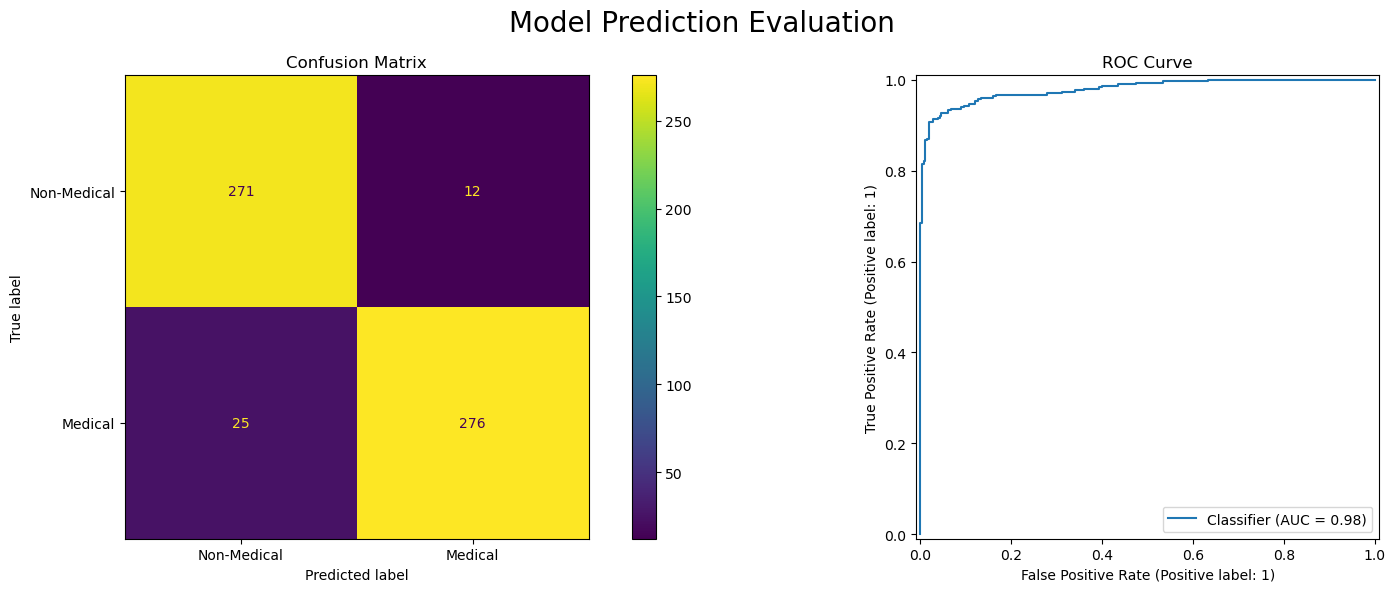

19/19 [==============================] - 0s 353us/step
Predictions - Non-Medical: 288 out of 584
Predictions - Misclassified: 37 out of 584
Example Misclassifications


,query,query-label-expert,query-is-non-medical-actual,query-is-non-medical-predicted
17,How to feed my fish when I'm gone?? Help!,999,True,False
38,How close to death was I?,1,False,True
59,ELI5 How Name Brand Medications And Other Prod...,999,True,False
60,Why does my scalp get itchy when I eat spicy f...,999,True,False
64,What circumstances make death instant?,1,False,True
68,"Nurses/doctors of reddit, what is the most hum...",999,True,False
77,Is the book Wheat Belly pseudoscience?,999,True,False
83,How can I gain weight?,1,False,True
104,What is blood pressure ?,1,False,True
108,What would cause charlie horses in feet when y...,1,False,True


In [9]:
# Compare Model Results
#

# Evaluate the models & get original query text
evaluate_model(base_model, X_test, y_test)
query_predictions_df = query_predictions(query_df, ids_test, X_test, base_model)
compare_predictions(query_predictions_df)

In [10]:
# Create random hyperrectangles based on embeddings
#

# TODO: Really not sure if this is a valid way to generate a hyperrectangle??

def generate_hyperrectangles(embedding_data, num_rectangles):

    # Min and max bounds for each dimension
    min_bounds = np.min(embedding_data, axis=0)
    max_bounds = np.max(embedding_data, axis=0)
    dimensions_num = len(min_bounds)
    print(f'Hyperrectangles Creation - Embeddings dimensions: {dimensions_num}')
    
    # Create hyperrectangles, with random bounds
    # hyperrectangles = np.empty((num_rectangles, dimensions_num), dtype=object)
    hyperrectangles = np.empty((num_rectangles, dimensions_num, 2))


    for rect_idx in range(num_rectangles):
        lower = min_bounds + np.random.random(dimensions_num) * (max_bounds - min_bounds) * 0.5
        upper = lower + np.random.random(dimensions_num) * (max_bounds - lower) * 0.9

        for dim_idx in range(dimensions_num):
            # hyperrectangles[rect_idx, dim_idx] = (lower[dim_idx], upper[dim_idx])
            hyperrectangles[rect_idx, dim_idx] = [lower[dim_idx], upper[dim_idx]]

    
    # hyperrectangles = np.array(hyperrectangles)
    print(f'Hyperrectangles Creation - shape: {hyperrectangles.shape}')

    return hyperrectangles


In [11]:
# Core PGD Attack Generation - Using Hyperrectangles
#

def pgd_attack_batch(model, X_batch, y_batch, pgd_steps, eps, gamma):
    """
    Performs PGD attack on a batch of inputs.

    Args:
        model: The model to attack.
        x_batch: Batch of input data.
        y_batch: Batch of true labels.
        pgd_steps: Number of PGD steps.
        eps: Tuple containing (lower bounds, upper bounds) for each dimension from hyperrectangles.
        gamma: Step size for each PGD iteration.

    Returns:
        perturbed_x: Adversarial examples generated from the input batch.
    """

    # Make a copy of the input to avoid modifying the original data
    X_adv = tf.identity(X_batch)
    
    # Iterate the PGD
    for _ in range(pgd_steps):
        with tf.GradientTape() as tape:
            tape.watch(X_adv)                       # Records all operations, watches for gradient calc
            predictions = model(X_adv)              # Forward pass, prediction on current example
            loss = tf.keras.losses.sparse_categorical_crossentropy(y_batch, predictions)
        
        # Compute gradient of the loss w.r.t the input
        gradients = tape.gradient(loss, X_adv)
        
        # Apply perturbation based on sign of the gradient
        # Perform gradient ascent step in the direction that maximizes the loss
        # TODO: Better understand how this maximises the loss?
        signed_grad = tf.sign(gradients)
        X_adv = X_adv + gamma * signed_grad

        # Project back within the epsilon bounds,
        # - the hyperrectangle with upper and lower bounds for each dimension
        # - keep to within 0 and 1
        X_adv = tf.clip_by_value(X_adv, eps[0], eps[1])
        # X_adv = tf.clip_by_value(X_adv, 0.0, 1.0) 
        # TODO: Is this appropriate for embedding vectors that may be outside these bounds??

    return X_adv

In [ ]:
# Use PGD to attack a model
#

# TODO: Impact of attack varies with Gamm and also the hyperrectangle chosen
# TODO: How to generate random vectors within bounds?

model = base_model
pgd_steps = 10
num_rectangles = len(X_test) # TODO: How many rectangles to define?? Just 1??
gamma_multiplier = 750       # TODO: Higher Gamma increases strength, eg 75- high FPs

# Create a simple set of hyperrectangles: n * dimensions with upper/lower bounds
hyperrectangles = generate_hyperrectangles(X_test, num_rectangles)
# hyperrectangles_labels = np.full(len(hyperrectangles), 0)
# hyperrectangles_labels = y_test
hyperrectangles_labels = 1 - y_test # Targeted attack, flip lablels

# For example, oad the hyper-rectangles - Marco's
# mc_hyperrectangles = np.load(run_results_folder.joinpath('marco_hyperrectangles.npy'))
# mc_hyperrectangles_labels = np.full(len(hyperrectangles), 0)
# TODO: Why use blank labels? MARCO

# Define the bounds
# TODO: Which hyperrectangle to select?
rectangle_idx = 0
eps = tf.transpose(hyperrectangles[rectangle_idx])   # For each dimension, the hyperrectangle lower and ipper bounds
gamma = tf.expand_dims((eps[1] - eps[0]) / (pgd_steps * gamma_multiplier), axis=0)  # Step-size within the bounds

# Generate a adversarial attack examples - based on the X_text embeddings
X_test_adv = pgd_attack_batch(model, X_test, y_test, pgd_steps, eps, gamma)



Hyperrectangles Creation - Embeddings dimensions: 30
Hyperrectangles Creation - shape: (584, 30, 2)


In [ ]:
# Visualisation / Clustering
#

# TODO: Look at similarity, clustering etc of adversarial attack embeddings vs original sentances


19/19 [==============================] - 0s 352us/step

----Evaluation Result for: medical_safety_classifier -------
Recall (Sensitivity, TP Rate): 0.9169
Precision: 0.9583
F1 Score 0.9372
Specificity (1 - Fall-Out): 0.9576
MCC: 0.8742
-----------
Accuracy: 0.9366
Fall Out (FPR): 0.0424
Hamming Loss 0.0634
ROC-AUC Score 0.9794
Gini Index: 0.9588
-----------


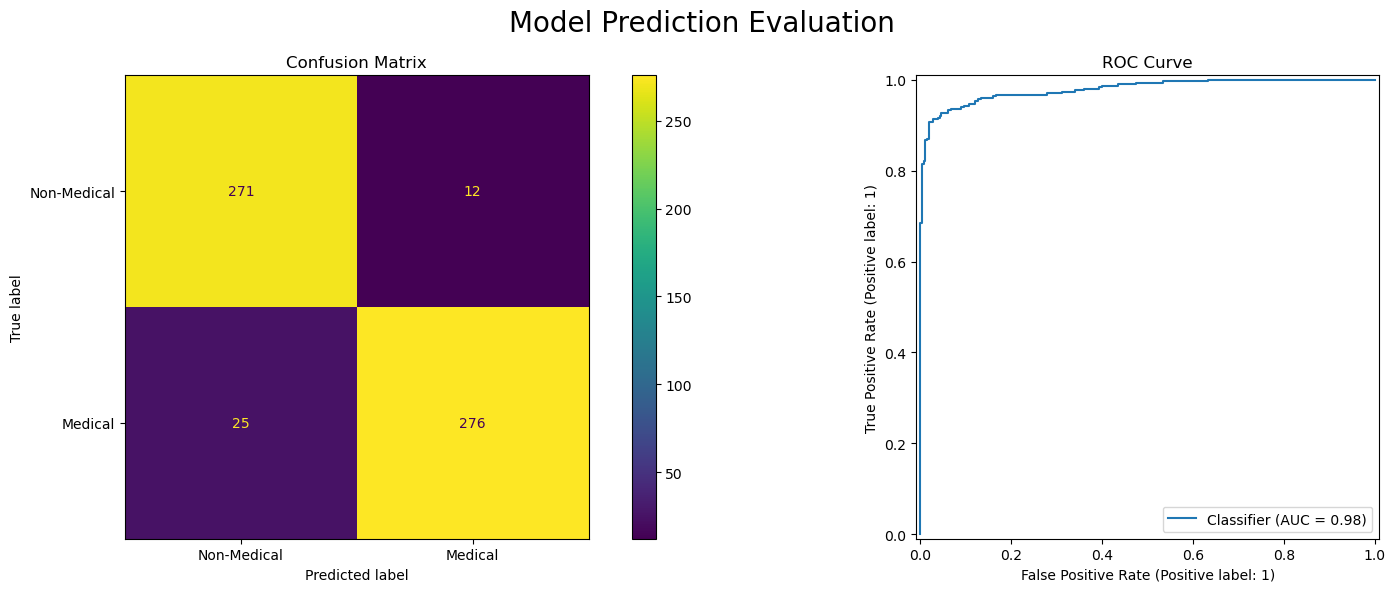

19/19 [==============================] - 0s 328us/step
Predictions - Non-Medical: 288 out of 584
Predictions - Misclassified: 37 out of 584
Example Misclassifications


,query,query-label-expert,query-is-non-medical-actual,query-is-non-medical-predicted
17,How to feed my fish when I'm gone?? Help!,999,True,False
38,How close to death was I?,1,False,True
59,ELI5 How Name Brand Medications And Other Prod...,999,True,False
60,Why does my scalp get itchy when I eat spicy f...,999,True,False
64,What circumstances make death instant?,1,False,True
68,"Nurses/doctors of reddit, what is the most hum...",999,True,False
77,Is the book Wheat Belly pseudoscience?,999,True,False
83,How can I gain weight?,1,False,True
104,What is blood pressure ?,1,False,True
108,What would cause charlie horses in feet when y...,1,False,True


19/19 [==============================] - 0s 305us/step

----Evaluation Result for: medical_safety_classifier -------
Recall (Sensitivity, TP Rate): 0.9900
Precision: 0.5379
F1 Score 0.6971
Specificity (1 - Fall-Out): 0.0954
MCC: 0.1934
-----------
Accuracy: 0.5565
Fall Out (FPR): 0.9046
Hamming Loss 0.4435
ROC-AUC Score 0.8368
Gini Index: 0.6737
-----------


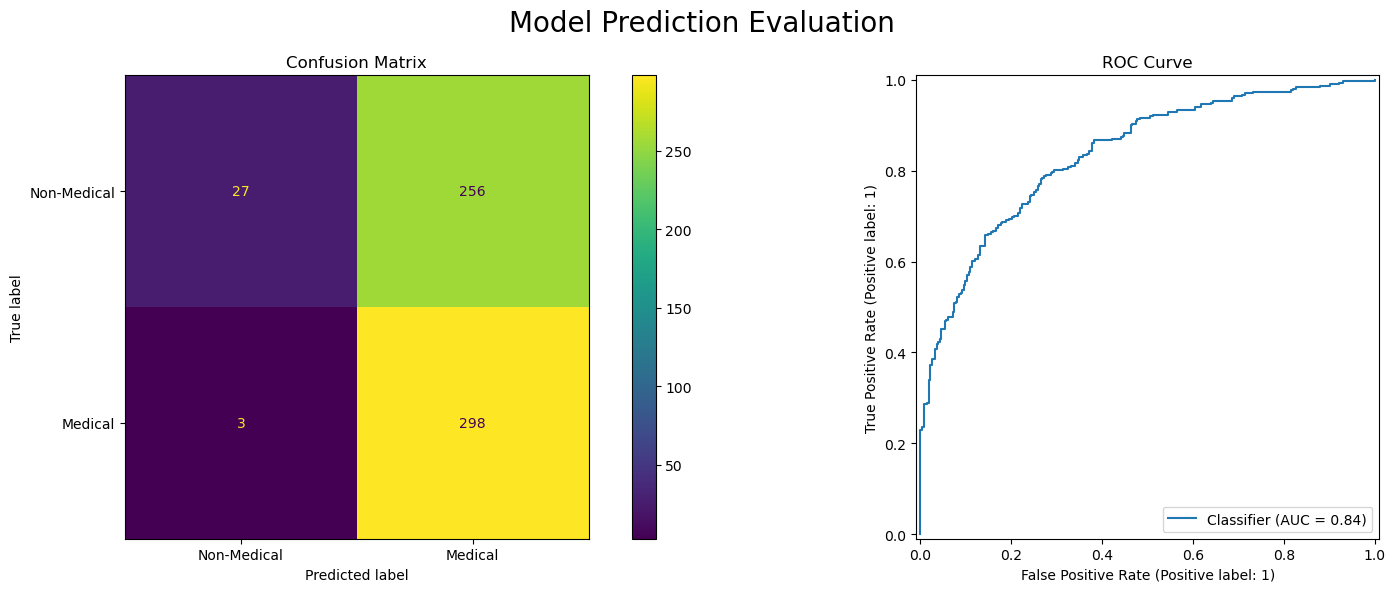

19/19 [==============================] - 0s 589us/step
Predictions - Non-Medical: 554 out of 584
Predictions - Misclassified: 259 out of 584
Example Misclassifications


,query,query-label-expert,query-is-non-medical-actual,query-is-non-medical-predicted
3,"[16 M] 2 days ago, I started having blood in p...",3,False,True
4,Can anyone explain the actual way minxodoil(ro...,1,False,True
9,Dull chest pain when bending in certain direct...,2,False,True
10,What is this skin peeling disease called?,1,False,True
12,What is this pink spot on my foot?,1,False,True
13,Weird medical incident today caused confusion ...,2,False,True
14,"help figuring out whats wrong with my, what me...",1,False,True
15,29 year old with bum neck. Any suggestions?,1,False,True
16,How much difference will it make to swelling/h...,1,False,True
18,[mental illness] does anyone know whats wrong ...,1,False,True


In [30]:
# Compare Model Results
#

# Evaluate the original & get original query text
evaluate_model(base_model, X_test, y_test)
query_predictions_df = query_predictions(query_df, ids_test, X_test, base_model)
compare_predictions(query_predictions_df)

# Evaluate the original with dversarial attack & get original query text
evaluate_model(base_model, X_test_adv, y_test)
adv_query_predictions_df = query_predictions(query_df, ids_test, X_test_adv, base_model)
compare_predictions(adv_query_predictions_df)

## OLD

In [ ]:
# Simple Adversarial attack
#

# TODO: Using the hyperrectangle for eps appears to make the X_adv converge??
# TODO: Hyperrectangle generation doesn't look right??

model = simple_model
pgd_steps = 10

# Use a single hyperrectangle for eps bounds

# t_hyperrectangle = tf.squeeze(tf.transpose(hyperrectangles))
# eps = tf.transpose(hyperrectangles[0])
# eps_lower = hyperrectangles[0][0]
# eps_upper = hyperrectangles[0][1]
# eps = (eps_lower, eps_upper)
# gamma = tf.reduce_max(eps_upper - eps_lower) / 10

hyperrectangles = generate_hyperrectangles(X_test, num_rectangles=1)
eps = hyperrectangles[0]
# eps = (-0.6, 0.6)
gamma = tf.reduce_max(eps[1] - eps[0]) / 10
gamma = tf.cast(gamma, tf.float64)

# Generate adversarial examples & evaluate the model using these
X_test_adv = pgd_attack_batch(model, X_test, y_test, pgd_steps, eps=eps, gamma=gamma)
evaluate_model(simple_model, X_test_adv, y_test)

# Examine predictions
query_predictions_df = query_predictions(query_dataset_df, ids_test, X_test_adv, simple_model)
compare_predictions(query_predictions_df)


## WIP

In [ ]:
# Generate adversarial attacks
#

model = simple_model

# Create random hyperrectangles with bounds of actual embeddings
hyperrectangles = generate_hyperrectangles(X_test, num_rectangles=5)
hyperrectangles_labels = np.full(len(hyperrectangles), 0)

# For each hyperrectangle, generate PGD vectors and labels
pgd_dataset = None
pgd_labels = None
for _, hyperrectangle in enumerate(hyperrectangles):

    # Get the lower and upper bounds for each dimension
    t_hyperrectangle = tf.transpose(hyperrectangle)


    # Run the PGD attack to generate adversarial examples
    X_adv = pgd_attack_batch(model, X_test, y_test, pgd_steps=10, eps=(-1,2), gamma=0.1 )

    if pgd_dataset is not None:
        pgd_dataset = tf.concat([pgd_dataset, pgd_point], axis=0)
        pgd_labels = tf.concat([pgd_labels, pgd_label], axis=0)
    else:
        pgd_dataset = pgd_point
        pgd_labels = pgd_label

# Evaluate the model
evaluate_model(simple_model, X_test_adv, y_test)

# Examine & Save Predictions
query_predictions_df = query_predictions(query_dataset_df, ids_test, X_test_adv, simple_model)
compare_predictions(query_predictions_df)


In [ ]:
# hyperrectangles, hyperrectangles_labels = get_hyperrectangles()
pgd_dataset = None
pgd_labels = None

model = simple_model
pgd_steps = 5
gamma_multiplier = 1000

for i, hyperrectangle in enumerate(hyperrectangles):
    # Extract the min and max bounds for each dimension (eps), transpose the hyperrectangle
    t_hyperrectangle = tf.transpose(hyperrectangle)
    # t_hyperrectangle = tf.transpose(tf.cast(hyperrectangle, tf.float32))


    # Calculate gamma (step size) from the hyperrectangle bounds
    gamma = tf.expand_dims((t_hyperrectangle[1] - t_hyperrectangle[0]) / (pgd_steps * gamma_multiplier), axis=0)

    # Generate random points in hyperrectangles
    pgd_point = tf.random.uniform(shape=[1, t_hyperrectangle.shape[-1]],
                                              minval=t_hyperrectangle[0],
                                              maxval=t_hyperrectangle[1])
    pgd_label = tf.expand_dims(hyperrectangles_labels[i], axis=0)

    # Run the PGD attack to generate adversarial examples
    pgd_point = pgd_attack_batch(model, pgd_point, pgd_label, pgd_steps, t_hyperrectangle, gamma)

    if pgd_dataset is not None:
        pgd_dataset = tf.concat([pgd_dataset, pgd_point], axis=0)
        pgd_labels = tf.concat([pgd_labels, pgd_label], axis=0)
    else:
        pgd_dataset = pgd_point
        pgd_labels = pgd_label

### xxxx

In [ ]:
def evaluate_attack(self, original_embeddings, adversarial_embeddings, 
                       true_labels, attack_name="Attack"):
        """
        Evaluate the success of adversarial attacks
        """
        # Get predictions for original and adversarial examples
        original_preds = tf.argmax(self.model(original_embeddings), axis=1)
        adversarial_preds = tf.argmax(self.model(adversarial_embeddings), axis=1)

        # Calculate attack success rate
        original_accuracy = tf.reduce_mean(
            tf.cast(original_preds == true_labels, tf.float32)
        )
        adversarial_accuracy = tf.reduce_mean(
            tf.cast(adversarial_preds == true_labels, tf.float32)
        )

        attack_success_rate = tf.reduce_mean(
            tf.cast(original_preds != adversarial_preds, tf.float32)
        )

        # Calculate perturbation statistics
        perturbation = adversarial_embeddings - original_embeddings
        l2_norm = np.mean(np.linalg.norm(perturbation, axis=1))
        linf_norm = np.mean(np.max(np.abs(perturbation), axis=1))

        results = {
            'original_accuracy': float(original_accuracy),
            'adversarial_accuracy': float(adversarial_accuracy),
            'attack_success_rate': float(attack_success_rate),
            'avg_l2_perturbation': l2_norm,
            'avg_linf_perturbation': linf_norm
        }

        print(f"\n{attack_name} Results:")
        print(f"Original Accuracy: {results['original_accuracy']:.4f}")
        print(f"Adversarial Accuracy: {results['adversarial_accuracy']:.4f}")
        print(f"Attack Success Rate: {results['attack_success_rate']:.4f}")
        print(f"Average L2 Perturbation: {results['avg_l2_perturbation']:.6f}")
        print(f"Average L∞ Perturbation: {results['avg_linf_perturbation']:.6f}")

        return results

### Hyperparameter tuning

In [ ]:
# Quick without a rebuild

model_best_tuned = tuner.hypermodel.build(best_hps)
model_best_tuned.fit(train_dataset_tf, epochs=50, validation_data=test_dataset_tf)



In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
model_temp = tuner.hypermodel.build(best_hps)
history = model_temp.fit(train_dataset_tf, epochs=50, validation_data=test_dataset_tf)

val_acc_per_epoch = history.history['val_binary_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (best_epoch,))

# Temp# Create a DataFrame with test queries and predictionstest_results_df = pd.DataFrame({    'query': X_text_test,    'actual_label': y_test,    'actual_safe': ["Safe" if label == 1 else "Unsafe" for label in y_test],    'predicted_prob': y_pred_probs.flatten(),    'predicted_binary': (y_pred_probs > 0.5).astype(int).flatten(),    'predicted_safe': ["Safe" if prob > 0.5 else "Unsafe" for prob in y_pred_probs.flatten()],    'correct_prediction': (y_test == (y_pred_probs > 0.5).astype(int).flatten())})print(f"Test results DataFrame shape: {test_results_df.shape}")print("\nFirst 5 rows:")display(test_results_df.head())

# Inspect queries and predictions - on the test dataset split
print(f"Correct predictions: {test_results_df['correct_prediction'].sum()}/{len(test_results_df)} ({test_results_df['correct_prediction'].mean():.3f})")

# Quick look at queries and predictions
for i in range(min(15, len(y_pred_probs))):
    query = X_text_test[i]
    actual_flag = "Safe" if y_test[i] == 1 else "Unsafe"
    predicted_prob = y_pred_probs[i][0]

# Predicted probabilities
y_pred_probs = simple_model.predict(X_test)

# Create a DataFrame with test queries and predictions
test_results_df = pd.DataFrame({    'query': X_text_test,    'actual_label': y_test,    'actual_safe': ["Safe" if label == 1 else "Unsafe" for label in y_test],    'predicted_prob': y_pred_probs.flatten(),    'predicted_binary': (y_pred_probs > 0.5).astype(int).flatten(),    'predicted_safe': ["Safe" if prob > 0.5 else "Unsafe" for prob in y_pred_probs.flatten()],    'correct_prediction': (y_test == (y_pred_probs > 0.5).astype(int).flatten())})print(f"Test results DataFrame shape: {test_results_df.shape}")print("\nFirst 5 rows:")
display(test_results_df.head())

print("\nPrediction accuracy summary:")
print(f"Correct predictions: {test_results_df['correct_prediction'].sum()}/{len(test_results_df)} ({test_results_df['correct_prediction'].mean():.3f})")

# Save the results DataFrame
test_results_df.to_pickle(data_folder.joinpath('test_results_with_predictions.pkl'))
print("\nSaved test results to 'test_results_with_predictions.pkl'")

# Quick look at queries and predictions
for i in range(min(15, len(y_pred_probs))):
    query = X_text_test[i]
    actual_flag = "Safe" if y_test[i] == 1 else "Unsafe"
    predicted_prob = y_pred_probs[i][0]

    print(f"{query}")
    print(f"- Actual: {actual_flag} vs Predicted: {predicted_prob:.2f}")

#
